In [5]:
!pip install numpy==1.23.5 pandas==1.5.3 scikit-learn==1.2.2 imbalanced-learn==0.10.1

     ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
     ---------------------------------------- 0.1/10.7 MB 1.3 MB/s eta 0:00:08
     ---------------------------------------- 0.1/10.7 MB 1.2 MB/s eta 0:00:10
      --------------------------------------- 0.2/10.7 MB 1.6 MB/s eta 0:00:07
      --------------------------------------- 0.2/10.7 MB 1.6 MB/s eta 0:00:07
      --------------------------------------- 0.2/10.7 MB 1.6 MB/s eta 0:00:07
     - -------------------------------------- 0.3/10.7 MB 1.1 MB/s eta 0:00:10
     - -------------------------------------- 0.3/10.7 MB 1.1 MB/s eta 0:00:10
     - -------------------------------------- 0.3/10.7 MB 1.1 MB/s eta 0:00:10
     - -------------------------------------- 0.3/10.7 MB 1.1 MB/s eta 0:00:10
     - -------------------------------------- 0.3/10.7 MB 1.1 MB/s eta 0:00:10
     - ------------------------------------- 0.4/10.7 MB 804.0 kB/s eta 0:00:13
     - ------------------------------------- 0.4/10.7 MB 8

  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [33 lines of output]
  Traceback (most recent call last):
    File "C:\Users\HP\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
      main()
    File "C:\Users\HP\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
      json_out['return_val'] = hook(**hook_input['kwargs'])
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\HP\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 112, in get_requires_for_build_wheel
      backend = _build_backend()
                ^^^^^^^^^^^^^^^^
    File "C:\Users\HP\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 77, in _build_backend
      obj = import_module(mod_path)
            ^^^^^^^^^^^^^^^^^^^^^^^
    File 


     ---------------------------- ---------- 7.9/10.7 MB 881.8 kB/s eta 0:00:04
     ----------------------------- --------- 8.0/10.7 MB 880.3 kB/s eta 0:00:04
     ----------------------------- --------- 8.0/10.7 MB 880.6 kB/s eta 0:00:04
     ----------------------------- --------- 8.0/10.7 MB 880.9 kB/s eta 0:00:04
     ----------------------------- --------- 8.1/10.7 MB 874.3 kB/s eta 0:00:04
     ----------------------------- --------- 8.1/10.7 MB 874.6 kB/s eta 0:00:04
     ----------------------------- --------- 8.2/10.7 MB 874.2 kB/s eta 0:00:03
     ----------------------------- --------- 8.2/10.7 MB 876.0 kB/s eta 0:00:03
     ----------------------------- --------- 8.2/10.7 MB 874.2 kB/s eta 0:00:03
     ----------------------------- --------- 8.2/10.7 MB 875.3 kB/s eta 0:00:03
     ------------------------------ -------- 8.3/10.7 MB 871.3 kB/s eta 0:00:03
     ------------------------------ -------- 8.3/10.7 MB 873.9 kB/s eta 0:00:03
     ------------------------------ ---

In [18]:
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

print("✅ Imports Done")

✅ Imports Done


In [19]:
df = pd.read_csv(r"C:\Users\HP\Desktop\fatal helth\fetal\fetal_health.csv")

# clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

df.head()

,baseline_value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


Shape: (2126, 22)

Class Distribution:
 1.0    1655
2.0     295
3.0     176
Name: fetal_health, dtype: int64


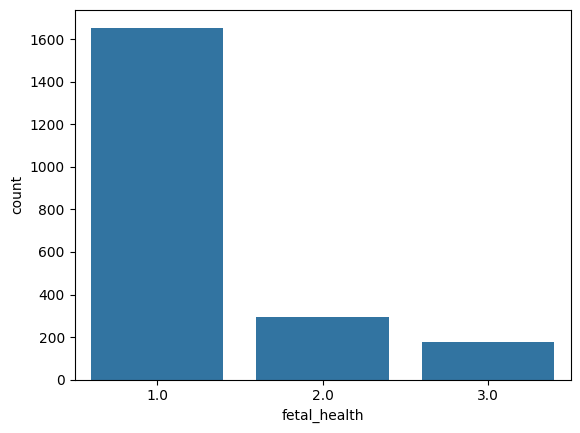

In [20]:
print("Shape:", df.shape)
print("\nClass Distribution:\n", df["fetal_health"].value_counts())

sns.countplot(x="fetal_health", data=df)
plt.show()

In [21]:
X = df.drop("fetal_health", axis=1)
y = df["fetal_health"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
y_pred = model.predict(X_test)

print("🔥 Accuracy:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

🔥 Accuracy: 0.9295774647887324

               precision    recall  f1-score   support

         1.0       0.97      0.95      0.96       332
         2.0       0.76      0.80      0.78        59
         3.0       0.84      0.91      0.88        35

    accuracy                           0.93       426
   macro avg       0.86      0.89      0.87       426
weighted avg       0.93      0.93      0.93       426



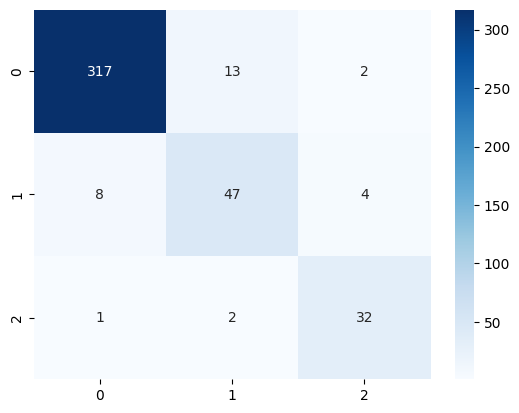

In [32]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()

In [38]:
!pip install ipywidgets

  Using cached fqdn-1.5.1-py3-none-any.whl.metadata (1.4 kB)
  Using cached isoduration-20.11.0-py3-none-any.whl.metadata (5.7 kB)
  Using cached uri_template-1.3.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached webcolors-25.10.0-py3-none-any.whl.metadata (2.2 kB)
Using cached webcolors-25.10.0-py3-none-any.whl (14 kB)
Using cached fqdn-1.5.1-py3-none-any.whl (9.1 kB)
Using cached isoduration-20.11.0-py3-none-any.whl (11 kB)
Using cached uri_template-1.3.0-py3-none-any.whl (11 kB)


In [41]:
import ipywidgets as widgets
widgets.IntSlider()

ModuleNotFoundError: No module named 'ipywidgets'

In [42]:
import numpy as np

print("👉 Enter 21 values (space separated):")

user_input = list(map(float, input().split()))

if len(user_input) != 21:
    print("❌ Please enter exactly 21 values")
else:
    data = np.array(user_input).reshape(1, -1)
    data = scaler.transform(data)

    pred = model.predict(data)[0]

    if pred == 1:
        print("\n✅ Prediction: Normal")
    elif pred == 2:
        print("\n⚠️ Prediction: Suspect")
    else:
        print("\n🚨 Prediction: Pathological")

👉 Enter 21 values (space separated):


 120 0.003 0 0.002 0 0 0 12 0.5 0 0.3 50 100 150 3 0 120 130 125 10 1


C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



✅ Prediction: Normal


In [ ]:
import numpy as np

print("---- Enter Details ----")

baseline_value = float(input("baseline_value: "))
accelerations = float(input("accelerations: "))
fetal_movement = float(input("fetal_movement: "))
uterine_contractions = float(input("uterine_contractions: "))
light_decelerations = float(input("light_decelerations: "))
severe_decelerations = float(input("severe_decelerations: "))
prolongued_decelerations = float(input("prolongued_decelerations: "))
abnormal_short_term_variability = float(input("abnormal_short_term_variability: "))
mean_value_of_short_term_variability = float(input("mean_value_of_short_term_variability: "))
percentage_of_time_with_abnormal_long_term_variability = float(input("long_term_variability: "))
mean_value_of_long_term_variability = float(input("mean_value_of_long_term_variability: "))
histogram_width = float(input("histogram_width: "))
histogram_min = float(input("histogram_min: "))
histogram_max = float(input("histogram_max: "))
histogram_number_of_peaks = float(input("histogram_peaks: "))
histogram_number_of_zeroes = float(input("histogram_zeroes: "))
histogram_mode = float(input("histogram_mode: "))
histogram_mean = float(input("histogram_mean: "))
histogram_median = float(input("histogram_median: "))
histogram_variance = float(input("histogram_variance: "))
histogram_tendency = float(input("histogram_tendency: "))

data = np.array([[
    baseline_value, accelerations, fetal_movement, uterine_contractions,
    light_decelerations, severe_decelerations, prolongued_decelerations,
    abnormal_short_term_variability, mean_value_of_short_term_variability,
    percentage_of_time_with_abnormal_long_term_variability,
    mean_value_of_long_term_variability, histogram_width, histogram_min,
    histogram_max, histogram_number_of_peaks, histogram_number_of_zeroes,
    histogram_mode, histogram_mean, histogram_median,
    histogram_variance, histogram_tendency
]])

data = scaler.transform(data)

pred = model.predict(data)[0]

if pred == 1:
    print("\n✅ Prediction: Normal")
elif pred == 2:
    print("\n⚠️ Prediction: Suspect")
else:
    print("\n🚨 Prediction: Pathological")

---- Enter Details ----


In [45]:
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("✅ Model Saved")

✅ Model Saved
